# **Exploratory 1**

Writen by: Atha Bintang Wahyu M.

In [70]:
# Base
import pandas as pd
import numpy as np 

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Stats
import statsmodels.api as sm
from scipy import sparse

# Spatial
import geopandas as gpd
import libpysal
from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda import Moran, Moran_Local
import spreg

# Data used
file_wiup = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/WIUP(Mas Kandar)/WIUP.shp"
file_desa_iup = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/Data/Desa_dengan_IUP/Desa_dengan_IUP.shp"
file_basemap = "/Users/athamawardi/Desktop/Research-Projects/KRE_Equity/id.json"

In [71]:
# Read GDF
gdf_wiup = gpd.read_file(file_wiup).set_index("objectid")
gdf_diup = gpd.read_file(file_desa_iup).set_index("OBJECTID")
gdf_basemap = gpd.read_file(file_basemap)

print(gdf_wiup.columns, gdf_diup.columns)

Index(['issuer', 'prov', 'idprov', 'kab', 'idkab', 'island', 'nmoprt',
       'tipopr', 'adoprt', 'phoprt', 'skblok', 'tiptmb', 'datstr', 'datend',
       'lublok', 'status', 'locate', 'idcmd', 'clascmd', 'commdt', 'idblok',
       'remark', 'srs_id', 'fcode', 'datcrte', 'geometry'],
      dtype='object') Index(['FID_WIUP_P', 'NAMOBJ', 'FCODE', 'REMARK', 'METADATA', 'SRS_ID',
       'KDBBPS', 'KDCBPS', 'KDCPUM', 'KDEBPS', 'KDEPUM', 'KDPBPS', 'KDPKAB',
       'KDPPUM', 'LUASWH', 'TIPADM', 'WADMKC', 'WADMKD', 'WADMKK', 'WADMPR',
       'WIADKC', 'WIADKK', 'WIADPR', 'WIADKD', 'UUPP', 'FID_WIUP',
       'objectid_1', 'issuer', 'prov', 'idprov', 'kab', 'idkab', 'island',
       'nmoprt', 'tipopr', 'adoprt', 'phoprt', 'skblok', 'tiptmb', 'datstr',
       'datend', 'lublok', 'status', 'locate', 'idcmd', 'clascmd', 'commdt',
       'idblok', 'remark_1', 'srs_id_1', 'fcode_1', 'datcrte', 'Shape_Leng',
       'Shape_Area', 'geometry'],
      dtype='object')


In [72]:
print(gdf_wiup.info(),
gdf_diup.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 4608 entries, 1.0 to 4608.0
Data columns (total 26 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   issuer    4608 non-null   object  
 1   prov      4608 non-null   object  
 2   idprov    4608 non-null   object  
 3   kab       4608 non-null   object  
 4   idkab     4608 non-null   object  
 5   island    4608 non-null   object  
 6   nmoprt    4608 non-null   object  
 7   tipopr    4608 non-null   object  
 8   adoprt    4608 non-null   object  
 9   phoprt    4608 non-null   object  
 10  skblok    4608 non-null   object  
 11  tiptmb    4608 non-null   object  
 12  datstr    4608 non-null   object  
 13  datend    4607 non-null   object  
 14  lublok    4608 non-null   float64 
 15  status    4608 non-null   object  
 16  locate    4608 non-null   object  
 17  idcmd     4608 non-null   object  
 18  clascmd   4608 non-null   object  
 19  commdt    4608 non-null   object  
 20  i

## Exploratory Data Analysis (EDA)

### 1. Numeric Summary Statistics

In [73]:
# WIUP: lublok = luas/blok (area in ha)
print("=== WIUP (Mining Licenses) - Numeric Summary ===\n")
print(gdf_wiup["lublok"].describe().to_string())
print(f"\nTotal area (lublok, ha): {gdf_wiup['lublok'].sum():,.0f}")
print(f"Missing: {gdf_wiup['lublok'].isna().sum()}")

print("\n" + "="*50)
print("\n=== Desa dengan IUP - Numeric Summary ===\n")
print("LUASWH (Village area):")
print(gdf_diup["LUASWH"].describe().to_string())
print("\nShape_Area (Geometry area):")
print(gdf_diup["Shape_Area"].describe().to_string())
print("\nlublok (WIUP area overlay):")
print(gdf_diup["lublok"].describe().to_string())

=== WIUP (Mining Licenses) - Numeric Summary ===

count      4608.000000
mean       1756.511475
std        5799.608461
min           0.000000
25%           8.447500
50%          53.390000
75%        1011.000000
max      130252.000000

Total area (lublok, ha): 8,094,005
Missing: 0


=== Desa dengan IUP - Numeric Summary ===

LUASWH (Village area):
count     14461.000000
mean       6775.202955
std       15839.716042
min           2.366190
25%         903.021334
50%        2357.018387
75%        6774.901771
max      300921.946585

Shape_Area (Geometry area):
count    1.446100e+04
mean     4.303683e-04
std      1.065935e-03
min      4.108531e-15
25%      4.361551e-06
50%      5.802403e-05
75%      3.882489e-04
max      2.371835e-02

lublok (WIUP area overlay):
count     14461.000000
mean       8133.153391
std       18318.152959
min           0.000000
25%          53.480000
50%        1681.000000
75%        7447.000000
max      130252.000000


### 2. Categorical Variable Analysis

In [ ]:
# WIUP - Key categorical variables
print("=== WIUP: Count by Province ===\n")
print(gdf_wiup["prov"].value_counts().to_string())

print("\n=== WIUP: Count by Island ===\n")
print(gdf_wiup["island"].value_counts().to_string())

print("\n=== WIUP: Count by tipopr (operation type) ===\n")
print(gdf_wiup["tipopr"].value_counts().to_string())

print("\n=== WIUP: Count by tiptmb (mineral type) ===\n")
print(gdf_wiup["tiptmb"].value_counts().head(15).to_string())

print("\n=== WIUP: Count by status ===\n")
print(gdf_wiup["status"].value_counts().to_string())

=== WIUP: Count by Province ===

prov
JAWA TIMUR                                    486
JAWA TENGAH                                   396
KALIMANTAN TIMUR                              369
KEPULAUAN BANGKA BELITUNG                     356
JAWA BARAT                                    331
KALIMANTAN TENGAH                             326
KALIMANTAN SELATAN                            252
SULAWESI TENGGARA                             216
KALIMANTAN BARAT                              212
SULAWESI TENGAH                               192
SUMATERA SELATAN                              177
DAERAH ISTIMEWA YOGYAKARTA                    163
JAMBI                                         147
SUMATERA BARAT                                124
MALUKU UTARA                                  106
SULAWESI SELATAN                              104
BANTEN                                         86
KEPULAUAN RIAU                                 68
NUSA TENGGARA TIMUR                            65
LAMPUNG     

In [ ]:
# Desa dengan IUP - Categorical
print("=== Desa dengan IUP: Count by Province (top 15) ===\n")
print(gdf_diup["prov"].value_counts().head(15).to_string())

print("\n=== Desa dengan IUP: Unique WIUP links (FID_WIUP_P) ===\n")
print(f"Unique WIUP polygons: {gdf_diup['FID_WIUP_P'].nunique()}")
print(f"Desa records: {len(gdf_diup)}")
print(f"Avg desa per WIUP: {len(gdf_diup) / gdf_diup['FID_WIUP_P'].nunique():.1f}")

=== Desa dengan IUP: Count by Province (top 15) ===

prov
KALIMANTAN TIMUR             1452
SUMATERA SELATAN             1245
KALIMANTAN SELATAN           1177
KALIMANTAN TENGAH            1161
SULAWESI TENGGARA             875
KEPULAUAN BANGKA BELITUNG     843
JAWA TIMUR                    842
JAWA TENGAH                   692
JAWA BARAT                    679
KALIMANTAN BARAT              671
MALUKU UTARA                  597
SULAWESI TENGAH               580
JAMBI                         477
SUMATERA UTARA                292
SULAWESI UTARA                283

=== Desa dengan IUP: Unique WIUP links (FID_WIUP_P) ===

Unique WIUP polygons: 7177
Desa records: 14461
Avg desa per WIUP: 2.0


### 3. Visualizations

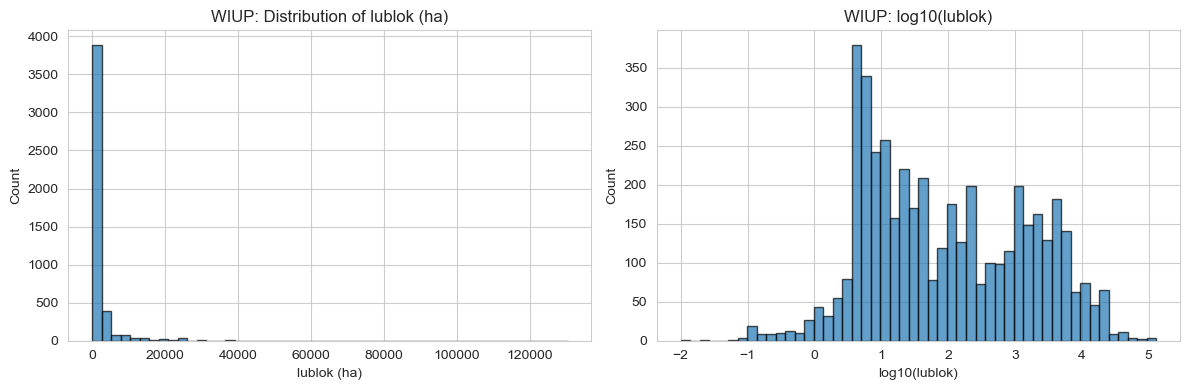

In [ ]:
# Set style
plt.rcParams["figure.figsize"] = (10, 4)
sns.set_style("whitegrid")

# WIUP area distribution (log-scale for skewness)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gdf_wiup["lublok"].hist(bins=50, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("WIUP: Distribution of lublok (ha)")
axes[0].set_xlabel("lublok (ha)")
axes[0].set_ylabel("Count")

# Log-transformed
np.log10(gdf_wiup["lublok"].clip(lower=0.01)).hist(bins=50, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("WIUP: log10(lublok)")
axes[1].set_xlabel("log10(lublok)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

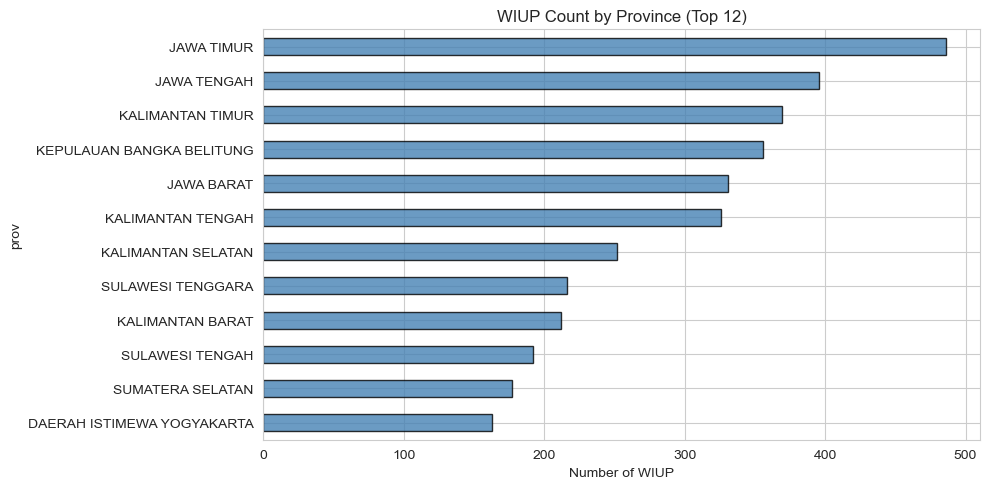

In [ ]:
# WIUP by Province (top 12) - Bar chart
top_prov = gdf_wiup["prov"].value_counts().head(12)
fig, ax = plt.subplots(figsize=(10, 5))
top_prov.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black", alpha=0.8)
ax.set_title("WIUP Count by Province (Top 12)")
ax.set_xlabel("Number of WIUP")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/97/_t7418h90z7_plcs1h17z0vh0000gn/T/ipykernel_60331/3263386616.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdf_wiup, x="island", y="log_lublok", palette="viridis")


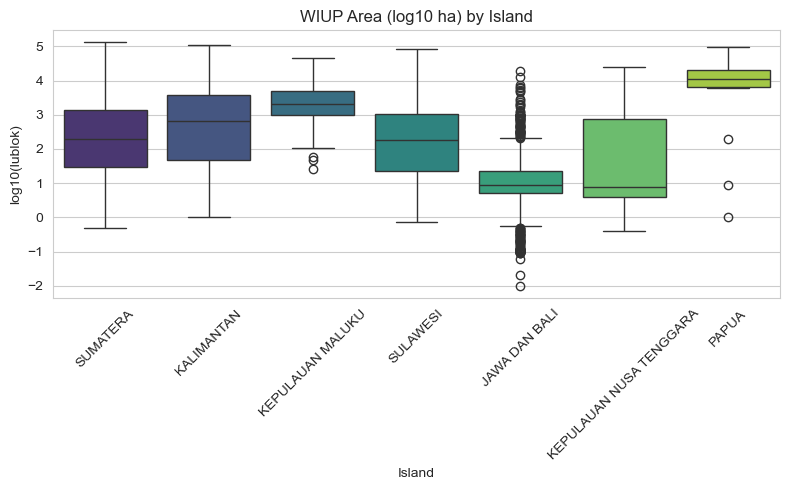

In [ ]:
# WIUP area (lublok) by Island - Box plot
gdf_wiup["log_lublok"] = np.log10(gdf_wiup["lublok"].clip(lower=0.01))
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=gdf_wiup, x="island", y="log_lublok", palette="viridis")
ax.set_title("WIUP Area (log10 ha) by Island")
ax.set_xlabel("Island")
ax.set_ylabel("log10(lublok)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

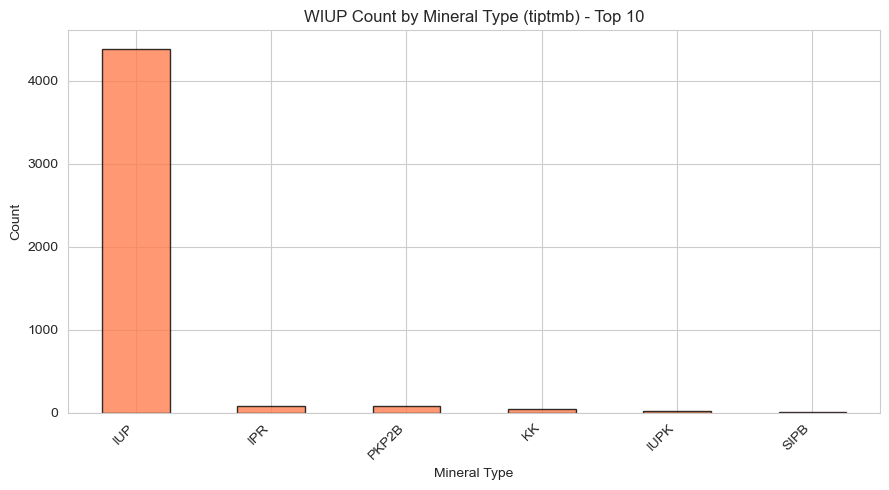

In [ ]:
# WIUP by mineral type (tiptmb) - Top 10
top_tiptmb = gdf_wiup["tiptmb"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 5))
top_tiptmb.plot(kind="bar", ax=ax, color="coral", edgecolor="black", alpha=0.8)
ax.set_title("WIUP Count by Mineral Type (tiptmb) - Top 10")
ax.set_xlabel("Mineral Type")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

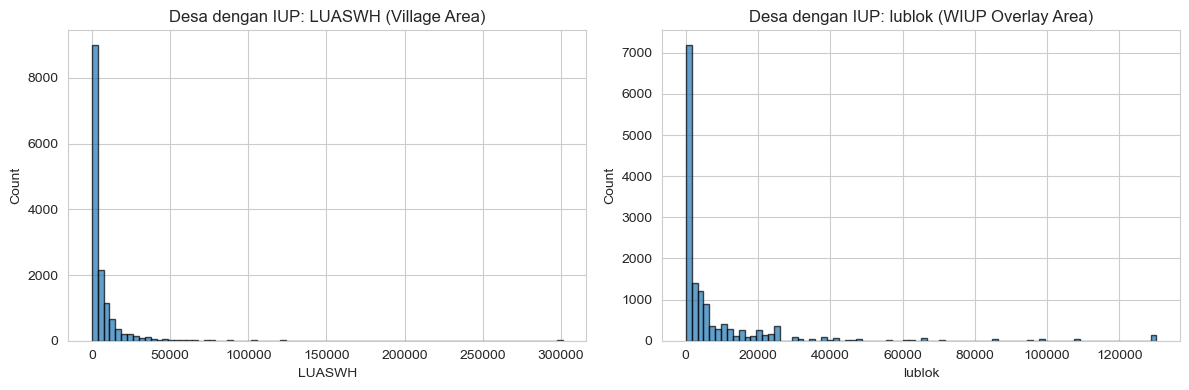

In [ ]:
# Desa dengan IUP: Distribution of village area (LUASWH) and WIUP overlay (lublok)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gdf_diup["LUASWH"].hist(bins=80, ax=axes[0], edgecolor="black", alpha=0.7)
axes[0].set_title("Desa dengan IUP: LUASWH (Village Area)")
axes[0].set_xlabel("LUASWH")
axes[0].set_ylabel("Count")

gdf_diup["lublok"].hist(bins=80, ax=axes[1], edgecolor="black", alpha=0.7)
axes[1].set_title("Desa dengan IUP: lublok (WIUP Overlay Area)")
axes[1].set_xlabel("lublok")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

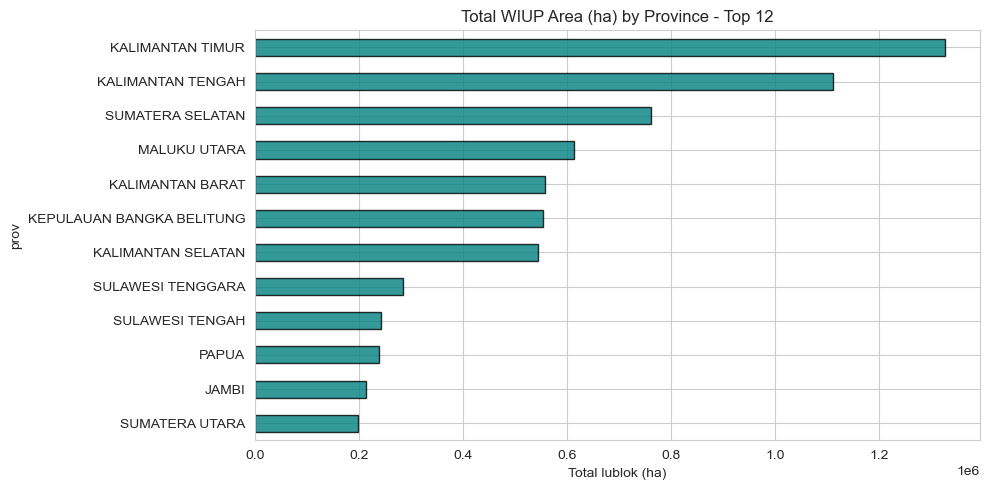

In [ ]:
# Aggregate: Total WIUP area (lublok) by province
area_by_prov = gdf_wiup.groupby("prov")["lublok"].sum().sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(10, 5))
area_by_prov.plot(kind="barh", ax=ax, color="teal", edgecolor="black", alpha=0.8)
ax.set_title("Total WIUP Area (ha) by Province - Top 12")
ax.set_xlabel("Total lublok (ha)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

=== IUP Overlap Ratio (lublok / LUASWH) ===

count    14461.000000
mean         0.489081
std          0.436874
min          0.000000
25%          0.033715
50%          0.368009
75%          1.000000
max          1.000000

Villages with 100% overlap: 5224
Villages with <10% overlap: 5195


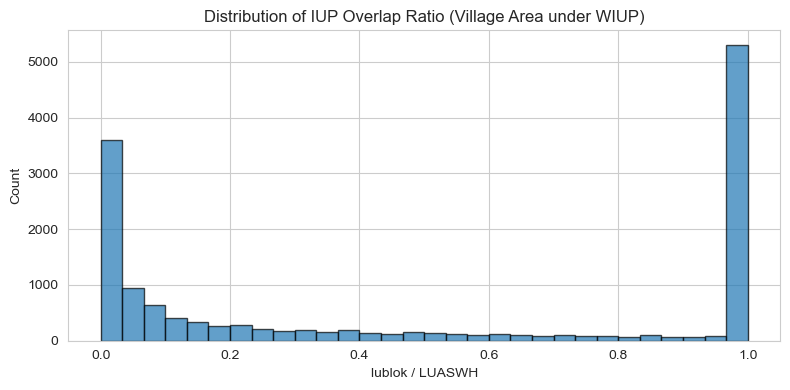

In [ ]:
# Desa dengan IUP: IUP overlap ratio (lublok / LUASWH) - % of village area under WIUP
gdf_diup["overlap_ratio"] = (gdf_diup["lublok"] / gdf_diup["LUASWH"].replace(0, np.nan)).clip(upper=1)
valid = gdf_diup["overlap_ratio"].dropna()
print("=== IUP Overlap Ratio (lublok / LUASWH) ===\n")
print(valid.describe().to_string())
print(f"\nVillages with 100% overlap: {(valid >= 0.999).sum()}")
print(f"Villages with <10% overlap: {(valid < 0.1).sum()}")

fig, ax = plt.subplots(figsize=(8, 4))
valid.hist(bins=30, ax=ax, edgecolor="black", alpha=0.7)
ax.set_title("Distribution of IUP Overlap Ratio (Village Area under WIUP)")
ax.set_xlabel("lublok / LUASWH")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Maps: Villages under IUP (SHP)

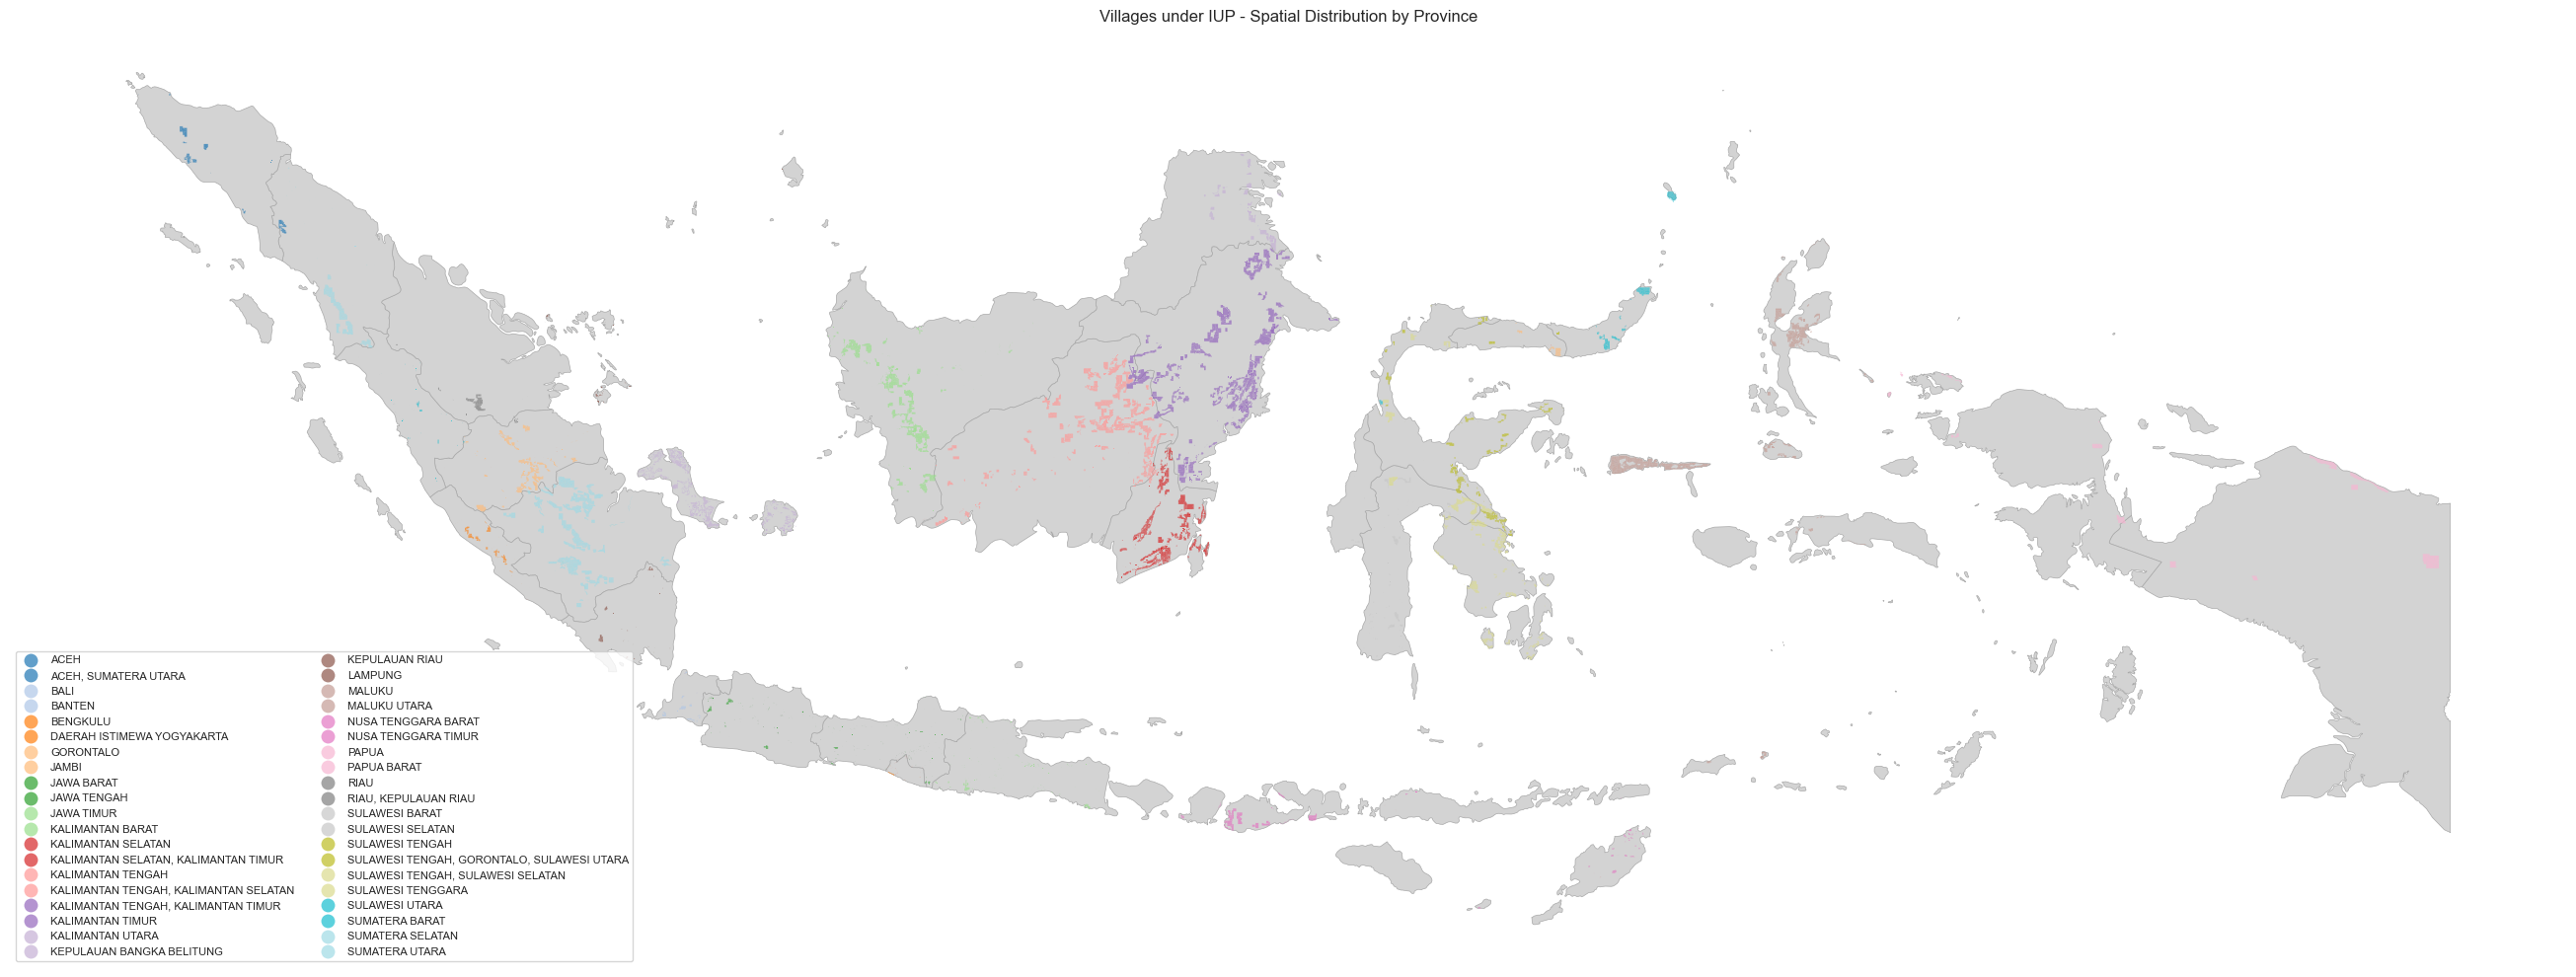

In [ ]:
# Map 1: Spatial distribution of all villages under IUP, colored by province
fig, ax = plt.subplots(figsize=(30, 10))
gdf_basemap.plot(ax=ax, facecolor="lightgray", edgecolor="darkgray", linewidth=0.5, zorder=0)
gdf_diup.plot(ax=ax, column="prov", cmap="tab20", legend=True, 
              legend_kwds={"loc": "lower left", "ncol": 2, "fontsize": 8}, alpha=0.7, edgecolor="none", zorder=1)
ax.set_title("Villages under IUP - Spatial Distribution by Province")
ax.axis("off")
plt.tight_layout()
plt.show()

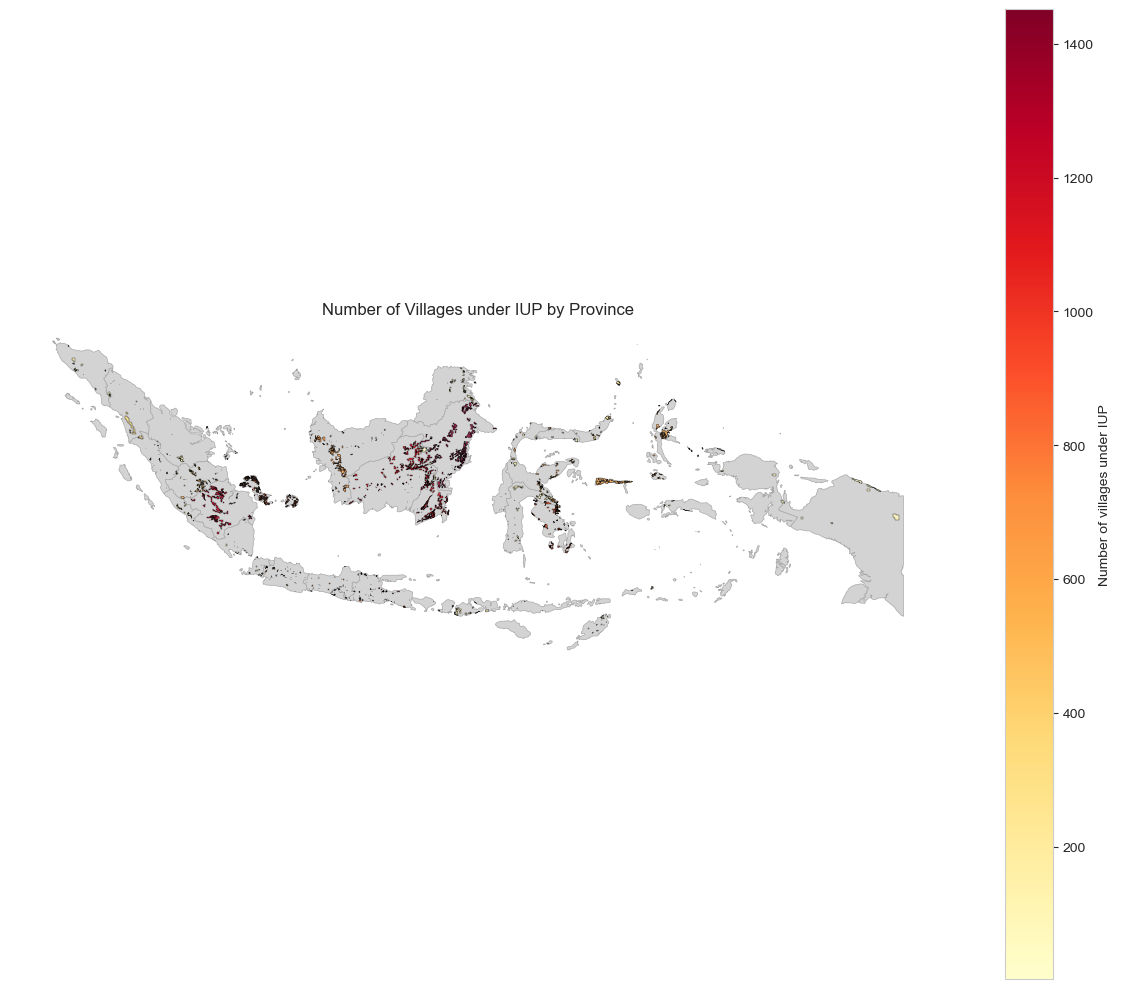

In [84]:
# Map 2: Choropleth 
village_count_prov = gdf_diup.groupby("prov").size()
gdf_prov = gdf_diup.dissolve(by="prov")
gdf_prov["n_villages"] = village_count_prov

fig, ax = plt.subplots(figsize=(12, 10))
gdf_basemap.plot(ax=ax, facecolor="lightgray", edgecolor="darkgray", linewidth=0.5, zorder=0)
gdf_prov.plot(ax=ax, column="n_villages", cmap="YlOrRd", legend=True, 
              legend_kwds={"label": "Number of villages under IUP"}, alpha=0.8, edgecolor="black", linewidth=0.3, zorder=1)
ax.set_title("Number of Villages under IUP by Province")
ax.axis("off")
plt.tight_layout()
plt.show()